<span style="font-size:14px">

## Agent 시스템
Agent 시스템 = “생각하고 → 판단하고 → 행동하는 AI 구조”
<br>
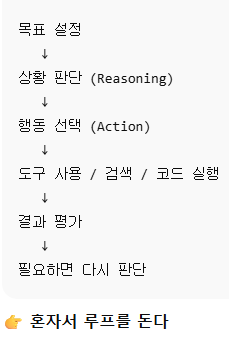

### Agent의 핵심 구성요소 (진짜 중요 ⭐)
- ① Goal (목표)
    - “논문 요약해줘”
    - “최신 주가 알려줘”
    - “이 질문에 정확한 답 찾아줘”
- ② Reasoning (추론)
    - 지금 정보가 충분한가?
    - 검색이 필요한가?
    - 문서 비교가 필요한가?
    - 👉 Chain of Thought / Planning
- ③ Action (행동)
    - 웹 검색
    - 벡터DB 조회
    - 코드 실행
    - 파일 읽기
    - Action: web_search("ViT 최신 논문")
- ④ Tool (도구)
    - 검색 엔진
    - DB
    - Python
    - API
- ⑤ Observation (관찰)
    - 도구 실행 결과
    - Observation: 논문 3개 발견
- ⑥ Loop (반복)
    - 아직 부족하면 다시 Reasoning → Action

In [ ]:
# 예시
from enum import Enum
class Status(Enum):
    PENDING=1
    RUNNING=2
    COMPLETED =3
    FAILED=4

task_status = Status.RUNNING
print(task_status)
print(task_status.name)
print(task_status.value)

Status.RUNNING
RUNNING
2


<span style="font-size:14px">

- 이 코드 정체
    - 상태(State) + 실행(Execute) + 기록(Log) + 통계(Stats)를 갖춘 상태 기반(Simple FSM) Agent 템플릿

- 핵심 4덩어리
    - ① 상태(State) : Agent 정체성 (Agent는 항상 지금 뭐하는 중인지 알아야함)
    - ② execute 흐름 (Lifecycle) : **매우중요**

        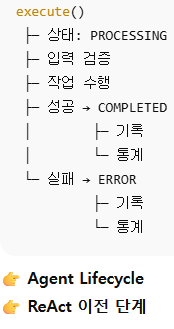
    
    - ③ 작업 처리 (_process) : 행동(action) 담당 --> LLM Agent로 바뀔자리 (LLM 판단 → Tool 선택)
    - ④ 기록 & 통계 (history / stats)


2️⃣ AgentState (상태 머신)
👉 Agent는 항상 “어디까지 왔는지”를 알아야 함

In [10]:
# final project에 사용해야함..

from enum import Enum

# 상태정의
class AgentState(Enum):
    '''에이전트 상태'''
    IDLE = 'idle'
    PROCESSING = 'processing'
    COMPLETED = 'completed'
    ERROR = 'error'


# 데이터 클래스
from typing import Dict, Any, Optional, List
from dataclasses import dataclass, asdict

@dataclass  # @ 이거 쓰면 __init__, __repr__, __eq__ 자동생성됨. 데이터 저장용 객체로 명확하게 만듦.
class ExecutionRecord:   # 실행기록
    '''실행기록'''
    timestamp:str   
    action:str
    status:str
    duration:float      # 실행시간
    error:Optional[str]=None

@dataclass
class AgentStats:
    '''에이전트 통계'''
    total_executed:int = 0
    success_count:int = 0
    error_count:int = 0
    total_time:float = 0.0
    avg_time:float = 0.0


# 에이전트 클래스
import uuid 
from datetime import datetime
class SimpleAgent:
    '''기본 에이이전트 구현
    - 상태를 관리
    - 작업을 실행
    - 인력을 기록
    - 통계를 추적
    '''
    def __init__(self, name:str='Agent', agent_type:str='simple'):
        self.agent_id=str(uuid.uuid4())[:8]
        self.name =name
        self.agent_type=agent_type

        # 파이썬은 완벽한 캡슐화가 되어 있지 않음. 파이썬은 접근제한이 없음. 모두 오픈. 
        # 그래서, _ 붙은 메서드는 클래스 내부에서만 사용하는 것으로 약속
        self._state = AgentState.IDLE  # 상태
        self._history : List[ExecutionRecord] = [] # 실행이력
        self._stats = AgentStats()  # 통계

        print(f"[success] {self.name} 에이전트 생성 (ID: {self.agent_id})") 

    

    # 상태 관리
    def get_state(self) -> str:
        '''현재 상태를 반환'''
        return self._state.name
    


    # 상태 변경
    def set_state(self, state:AgentState):   #getter setter ??
        '''현재 상태 변경'''
        self._state = state
        print(f"[STATE] [{self._state.name}] 상태 변경: {self._state.value}")



    # execute : Agent의 lifecycle을 보여줌
        # IDLE
        #  ↓
        # PROCESSING
        #  ↓
        # 입력 검증
        #  ↓
        # 작업 수행
        #  ↓
        # COMPLETED or ERROR
        #  ↓
        # 기록 + 통계
    # 작업 실행
    def execute(self, input_data:Dict[str,Any]) -> Dict[str,Any]:
        '''작업 실행(메인 메소드)'''
        start_time = datetime.now()
        self.set_state(AgentState.PROCESSING)
        try:
            # 입력 검증
            if not self._validate_input(input_data):
                raise ValueError('입력 데이터가 유효하지 않습니다')
            
            # 실제 작업 수행
            action = input_data.get('action', 'unknown')
            result = self._process(action, input_data)
            
            # 성공 처리
            self.set_state(AgentState.COMPLETED)
            duration = (datetime.now() - start_time).total_seconds()

            # 히스토리 관리
            self._add_to_history(action, 'success', duration)
            self._update_stats(success=True, duration=duration)

            return {
                'success' : True,
                'agent_id' : self.agent_id,
                'action' : action,
                'output' : result,
                'duration' : duration
            }
            
        except Exception as e:
            # 오류 처리
            self.set_state(AgentState.ERROR)
            duration = (datetime.now() - start_time).total_seconds()
            error_msg = str(e)
            self._add_to_history(action, 'error', duration, error_msg)
            self._update_stats(success=False, duration=duration)

            return {
                'success' : False,
                'agent_id' : self.agent_id,
                'error' : error_msg,
                'duration' : duration
            }



    # 작업 처리    
    def _process(self, action:str, input_data:Dict[str,Any]) -> Any:
            '''실제 작업 수행'''
            if action == 'greet':
                name = input_data.get('name', 'Guest')
                return f"Hello, {name}"
            elif action == 'add':
                a = input_data.get('a', 0)
                b = input_data.get('b', 0)
                print(f"계산 : {a} + {b} = {a+b}")
                return a+b
            elif action =='muliply':
                a = input_data.get('a', 0)
                b = input_data.get('b', 0)
                print(f"계산 : {a} x {b} = {a*b}")
                return a*b
            elif action == 'uppercase':
                text = input_data.get('text', '')
                result = text.upper()
                print(f"변환 : {text} -> {result}")
                return result
            elif action == 'lowercase':
                text = input_data.get('text', '')
                result = text.lower()
                print(f"변환 : {text} -> {result}")
                return result
            else:
                raise ValueError(f'알수 없는 작업: {action}')
    

    # 검증 및 기록
    def _validate_input(self, input_data:Dict[str,Any]) -> bool:
        '''입력 검증'''
        if not isinstance(input_data, dict):
            print(f"[ERROR] 입력은 딕셔너리여야 합니다.")
            return False
        if 'action' not in input_data:
            print(f"[ERROR] action 키는 필수입니다.")
            return False
        return True
    def _add_to_history(self, action:str, status:str, duration:float, error:Optional[str]=None):
        '''이력 추가'''
        record = ExecutionRecord(
            timestamp=datetime.now().isoformat(),
            action=action,
            status=status,
            duration=duration,
            error=error
        )
        self._history.append(record)
        if len(self._history) > 100: # 최대 100개만 유지
            self._history.pop(0)
    def _update_stats(self, success:bool, duration:float):
        '''통계 업데이트'''
        self._stats.total_executed += 1
        if success:
            self._stats.success_count += 1
        else:
            self._stats.error_count += 1
        self._stats.total_time += duration
        self._stats.avg_time = self._stats.total_time / self._stats.total_executed


    
    # 정보조회
    def get_info(self) -> Dict[str, Any]:
        """에이전트 정보 반환"""
        return {
            "id": self.agent_id,
            "name": self.name,
            "type": self.agent_type,
            "state": self.get_state(),
            "history_size": len(self._history),
            "stats": asdict(self._stats)
        }
    
    def get_history(self) -> List[Dict[str, Any]]:
        """실행 이력 반환"""
        return [asdict(record) for record in self._history]
    
    def print_info(self):
        """에이전트 정보 출력"""
        info = self.get_info()
        print("\\n" + "="*60)
        print(f"[INFO] {self.name} 에이전트 정보")
        print("="*60)
        print(f"ID: {info['id']}")
        print(f"타입: {info['type']}")
        print(f"상태: {info['state']}")
        print(f"이력 개수: {info['history_size']}")
        print(f"\\n[STATS] 통계:")
        stats = info['stats']
        print(f"  - 총 실행: {stats['total_executed']}회")
        print(f"  - 성공: {stats['success_count']}회")
        print(f"  - 실패: {stats['error_count']}회")
        print(f"  - 평균 시간: {stats['avg_time']:.3f}초")
        print("="*60 + "\n")


if __name__ == '__main__':
    # 에이전트 생성
    agent = SimpleAgent('Worker', 'simple')
    test_case = [
        {'action' : 'greet', 'name':'hong-gil-dong'},
        {'action' : 'add', 'a':10, 'b':20},
        {'action' : 'uppercase', 'text':'hello-world'},
        {'action' : 'count_words', 'text': 'hello my name is hong'},
    ]

    for task in test_case:
        result = agent.execute(task)
        if result ['success']:
            print(f" [OK] : {result['output']}")
        else:
            print(f"[FAIL] : {result['error']}")
        

    # 에이전트 정보출력
    agent.print_info()

    # 이력 출력
    history = agent.get_history()
    for his in history[:5]: # 최근 5개만 보겠다
        print(his)

[success] Worker 에이전트 생성 (ID: 77e08b94)
[STATE] [PROCESSING] 상태 변경: processing
[STATE] [COMPLETED] 상태 변경: completed
 [OK] : Hello, hong-gil-dong
[STATE] [PROCESSING] 상태 변경: processing
계산 : 10 + 20 = 30
[STATE] [COMPLETED] 상태 변경: completed
 [OK] : 30
[STATE] [PROCESSING] 상태 변경: processing
변환 : hello-world -> HELLO-WORLD
[STATE] [COMPLETED] 상태 변경: completed
 [OK] : HELLO-WORLD
[STATE] [PROCESSING] 상태 변경: processing
[STATE] [ERROR] 상태 변경: error
[FAIL] : 알수 없는 작업: count_words
\n============================================================
[INFO] Worker 에이전트 정보
ID: 77e08b94
타입: simple
상태: ERROR
이력 개수: 4
\n[STATS] 통계:
  - 총 실행: 4회
  - 성공: 3회
  - 실패: 1회
  - 평균 시간: 0.000초

{'timestamp': '2025-12-16T11:05:17.822423', 'action': 'greet', 'status': 'success', 'duration': 0.0, 'error': None}
{'timestamp': '2025-12-16T11:05:17.822423', 'action': 'add', 'status': 'success', 'duration': 0.0, 'error': None}
{'timestamp': '2025-12-16T11:05:17.822423', 'action': 'uppercase', 'status': 'success', 'duration

In [ ]:
# uuid 예시
import uuid
for i in range(5):
    print(str(uuid.uuid1()))

67d15c0d-da16-11f0-ad66-f4b30129752e
67d1830e-da16-11f0-991f-f4b30129752e
67d1830f-da16-11f0-9184-f4b30129752e
67d18310-da16-11f0-bdd1-f4b30129752e
67d18311-da16-11f0-a53a-f4b30129752e
